# Width and depth in a ReLU classifier

In the previous notebook, a hidden layer bent a one-dimensional function. With two input coordinates, the same operation has a geometric interpretation: each ReLU unit folds the input plane along a line, and the output layer combines the folded pieces into class scores. The decision boundary is where those scores are equal.

This notebook follows one question from the first fold to a trained classifier: what does a wider layer add, and what does an additional layer make possible? We will first look at one neuron, then compare width and depth using deliberately simple constructions, and finally train the same classification problem with both architectures.

## 1. One neuron: from a line to a ReLU unit

For `x=(x1,x2)`, a neuron computes `z=w1*x1+w2*x2+b`, then `h=ReLU(z)=max(0,z)`. Its zero set `z=0` is a line. On one side, the output is identically zero; on the other, the output follows the affine plane `z`. The surface has a ReLU unit at that line.

“Folding the input” is a geometric shorthand. The input coordinates do not move; instead, points on the inactive side receive the same zero feature from that neuron, while active points retain a graded feature. Later neurons combine these features. This is why a fold line is not automatically a classifier’s decision boundary.

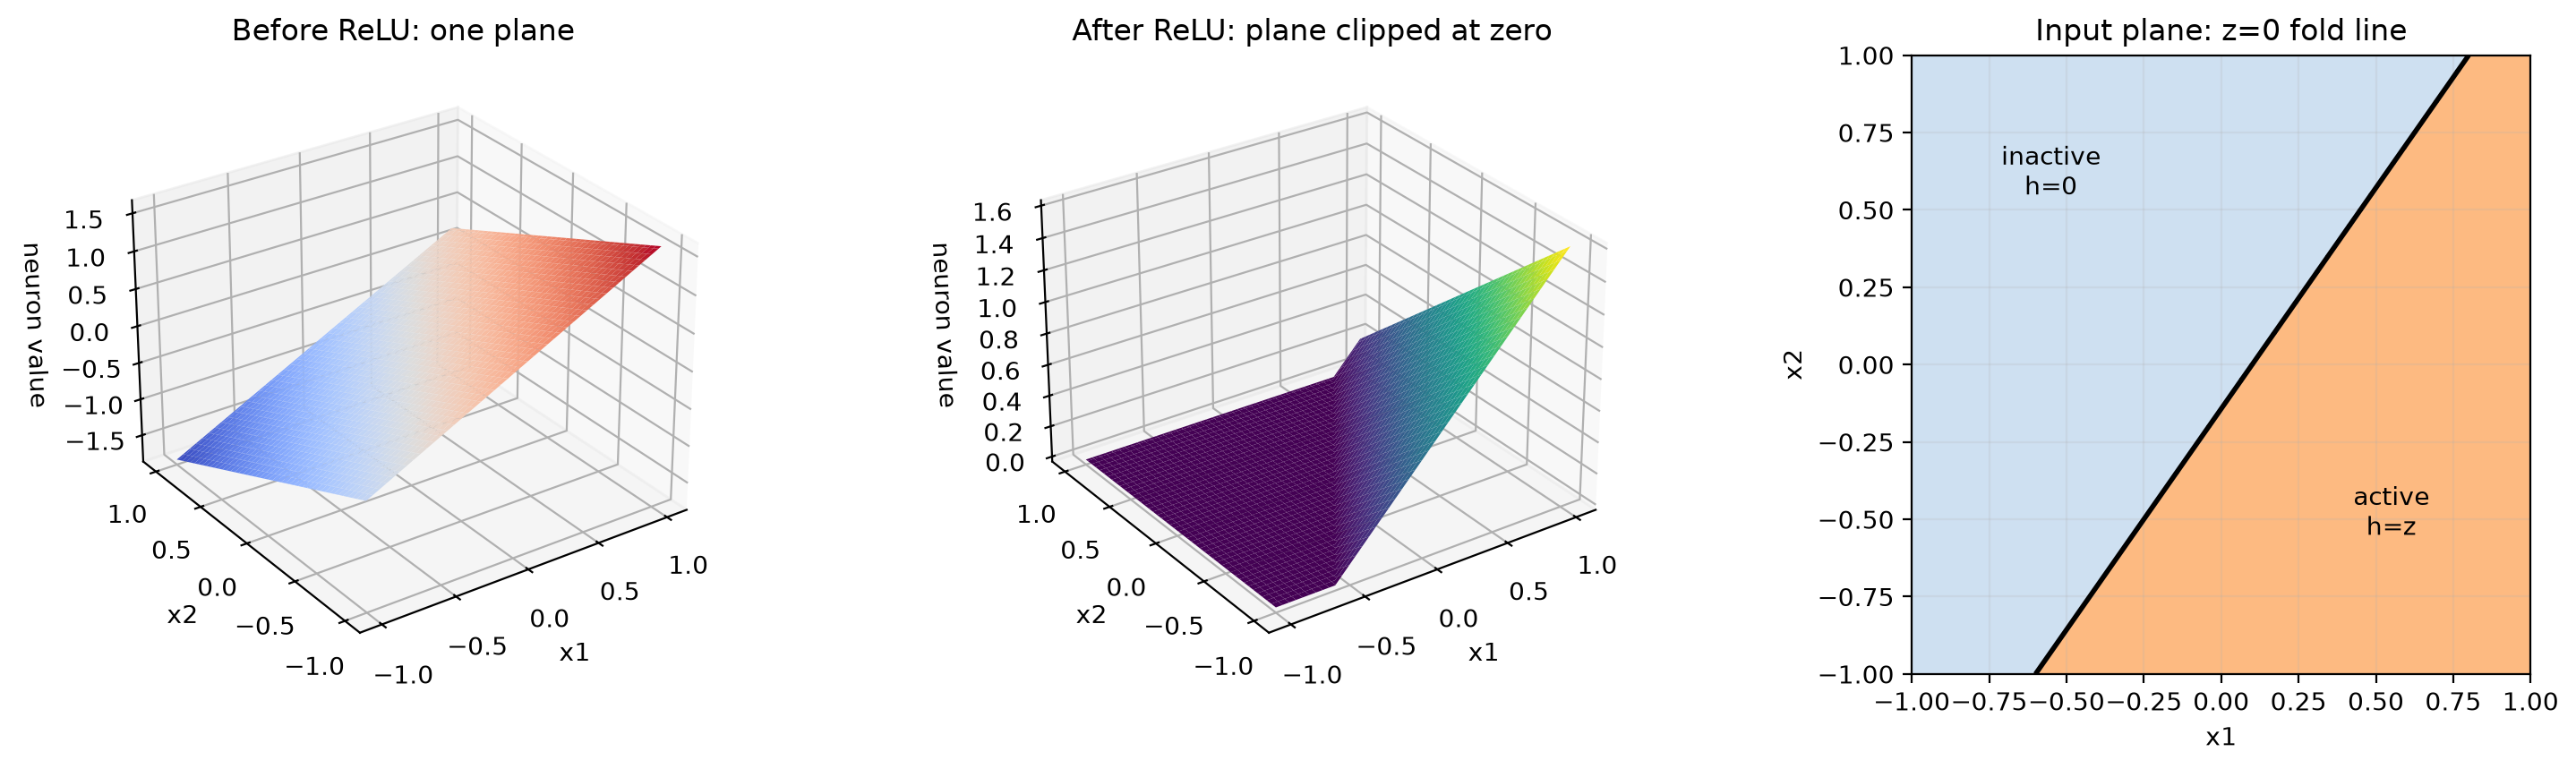

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.figsize': (7, 5), 'axes.grid': True, 'grid.alpha': .2})
def relu(z): return np.maximum(z, 0.)

grid = np.linspace(-1, 1, 401)
X, Y = np.meshgrid(grid, grid)
w1, w2, b = 1., -.7, -.1
Z = w1*X + w2*Y + b
H = relu(Z)
fig = plt.figure(figsize=(15,4.4))
for i,(A,title,cmap) in enumerate([(Z,'Before ReLU: one plane','coolwarm'),(H,'After ReLU: plane clipped at zero','viridis')],1):
    ax=fig.add_subplot(1,3,i,projection='3d')
    ax.plot_surface(X,Y,A,cmap=cmap,linewidth=0,antialiased=True)
    ax.set(xlabel='x1',ylabel='x2',zlabel='neuron value',title=title)
    ax.view_init(elev=28,azim=-125)
ax=fig.add_subplot(1,3,3)
ax.contourf(X,Y,Z,levels=[Z.min(),0,Z.max()],colors=['#c6dbef','#fdae6b'],alpha=.85)
ax.contour(X,Y,Z,levels=[0],colors='black',linewidths=2)
ax.set(xlim=(-1,1),ylim=(-1,1),xlabel='x1',ylabel='x2',title='Input plane: z=0 fold line',aspect='equal')
ax.text(-.55,.55,'inactive\nh=0',ha='center'); ax.text(.55,-.55,'active\nh=z',ha='center')
plt.tight_layout(); plt.show()

The black line is the zero set of the neuron's affine score. It divides the input into an inactive half-plane, where the ReLU output is zero, and an active half-plane, where the output is the original affine function. That crease is the basic object that every later construction reuses.

With several first-layer neurons, each line adds another possible change in the affine rule. The intersections partition the input into cells. Inside one cell, every neuron has a fixed active or inactive status, so the whole network is affine there.

## 2. Width: adding ReLU neurons to one layer

To isolate width, we use a boundary that is a function of `x1`. A one-hidden-layer ReLU network can represent a piecewise-linear approximation by adding shifted ReLU activations:

```text
g(x1) = a + s x1 + sum_j c_j ReLU(x1 - t_j)
```

The value `t_j` is the input location where neuron `j` changes from inactive to active. Each additional first-layer neuron gives the output another place where its slope can change. The class boundary is the zero contour of `g(x1) - x2`.

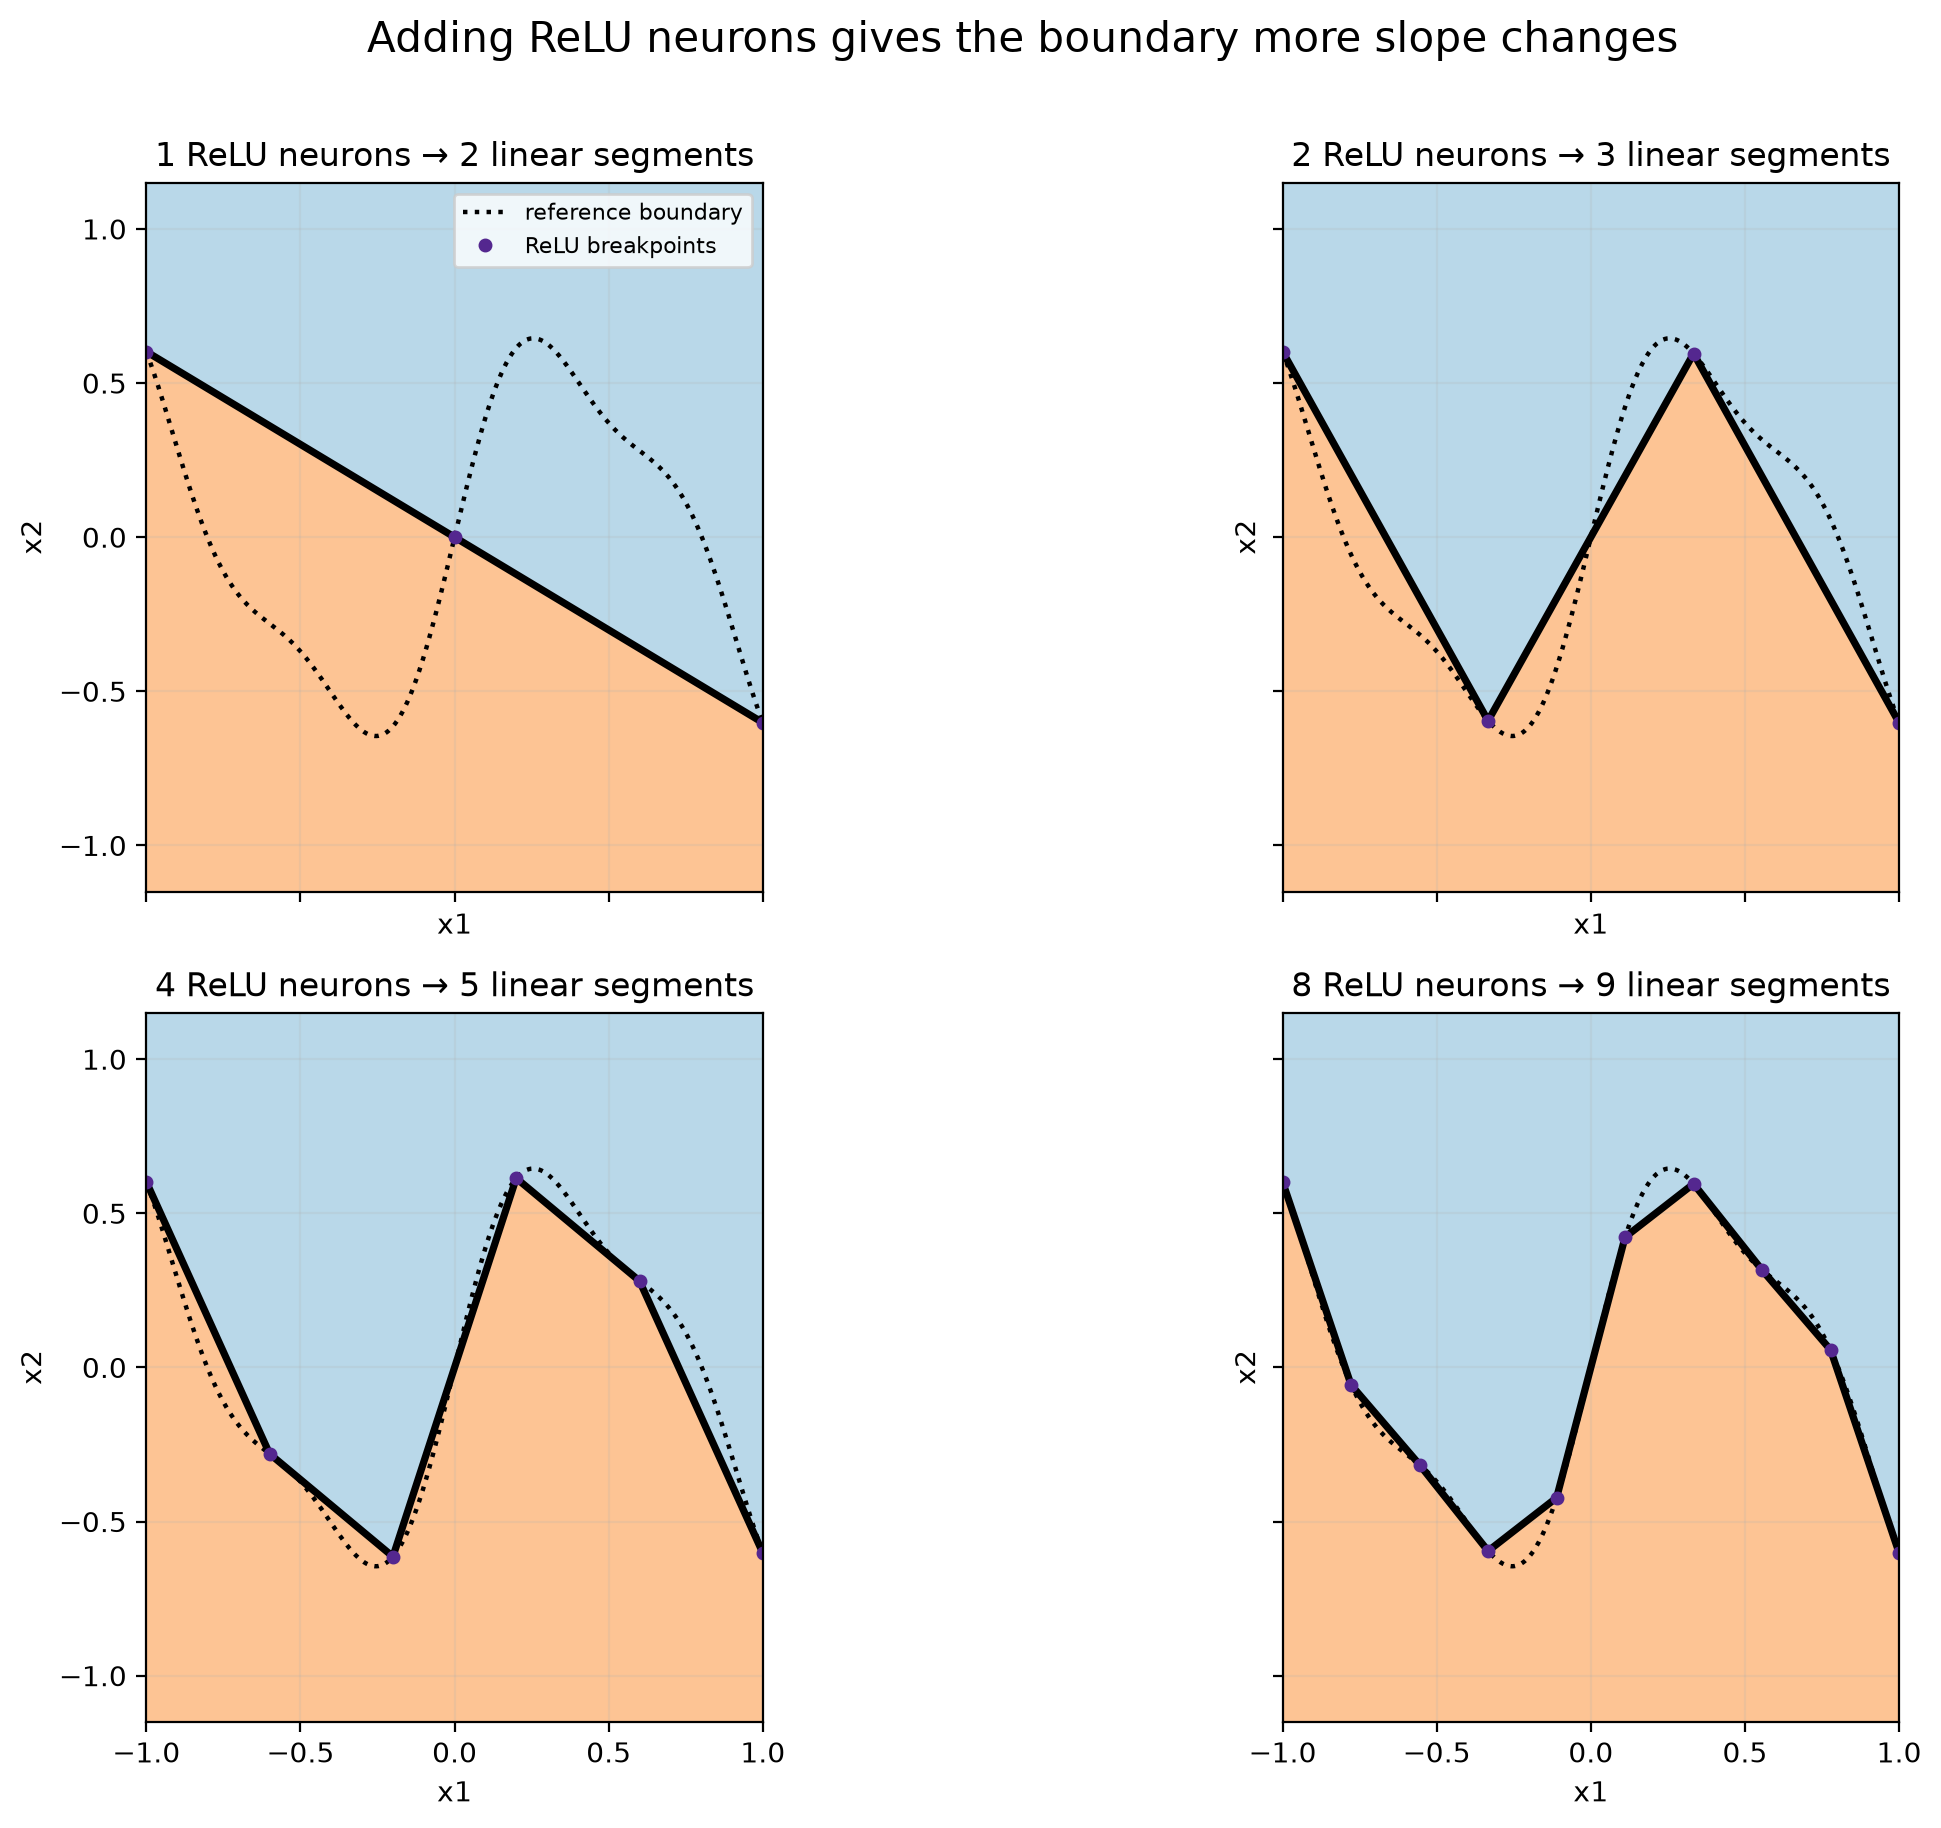

In [2]:
def target_boundary(x):
    """Smooth curve used as the reference classification boundary."""
    slow_wave = 0.62 * np.sin(1.35 * np.pi * x)
    fast_wave = 0.16 * np.sin(3.1 * np.pi * x)
    return slow_wave + fast_wave


def relu(value):
    """Rectified linear activation: keep positive values, replace negatives by zero."""
    return np.maximum(value, 0)


def piecewise_linear_boundary(x, breakpoints):
    """Interpolate the reference curve using shifted ReLU activations.

    The first line gives the initial straight segment. Each interior breakpoint
    adds one ReLU neuron and changes the slope after that breakpoint.
    """
    breakpoints = np.asarray(breakpoints, dtype=float)
    boundary_values = target_boundary(breakpoints)
    segment_slopes = np.diff(boundary_values) / np.diff(breakpoints)

    first_slope = segment_slopes[0]
    first_intercept = boundary_values[0] - first_slope * breakpoints[0]
    approximation = first_intercept + first_slope * x

    interior_breakpoints = breakpoints[1:-1]
    slope_changes = np.diff(segment_slopes)
    for breakpoint, slope_change in zip(interior_breakpoints, slope_changes):
        approximation = approximation + slope_change * relu(x - breakpoint)

    return approximation


x_values = np.linspace(-1, 1, 1200)
y_values = np.linspace(-1.15, 1.15, 600)
input_x, input_y = np.meshgrid(x_values, y_values)

breakpoint_counts = [3, 4, 6, 10]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for axis, number_of_breakpoints in zip(axes.flat, breakpoint_counts):
    breakpoints = np.linspace(-1, 1, number_of_breakpoints)
    approximated_boundary = piecewise_linear_boundary(input_x, breakpoints)
    class_score = approximated_boundary - input_y

    axis.contourf(
        input_x,
        input_y,
        class_score,
        levels=[class_score.min(), 0, class_score.max()],
        colors=['#9ecae1', '#fdae6b'],
        alpha=0.72,
    )
    axis.contour(input_x, input_y, class_score, levels=[0], colors='black', linewidths=2.6)
    axis.plot(x_values, target_boundary(x_values), 'k:', linewidth=1.6, label='reference boundary')
    axis.plot(
        breakpoints,
        target_boundary(breakpoints),
        'o',
        markersize=4,
        color='#54278f',
        label='ReLU breakpoints',
    )
    axis.set_title(
        f'{number_of_breakpoints - 2} ReLU neurons '
        f'→ {number_of_breakpoints - 1} linear segments'
    )
    axis.set_xlabel('x1')
    axis.set_ylabel('x2')
    axis.set_xlim(-1, 1)
    axis.set_ylim(-1.15, 1.15)
    axis.set_aspect('equal')

axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle('Adding ReLU neurons gives the boundary more slope changes', fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

The reference curve and the training setup are the same in every panel. Increasing the number of ReLU neurons adds more breakpoints, so the learned boundary can change slope more often. The blue and orange regions are the two class predictions; the black curve is the score tie; the purple points show where the ReLU representation is allowed to change slope.

## 3. A ReLU neuron folds the input along one line

The previous example used vertical breakpoints only because the boundary depended on `x1`. A general first-layer neuron computes `w1*x1 + w2*x2 + b`. Its activation changes at the line `w1*x1 + w2*x2 + b = 0`, which can have any orientation. This is the two-dimensional version of the same operation.

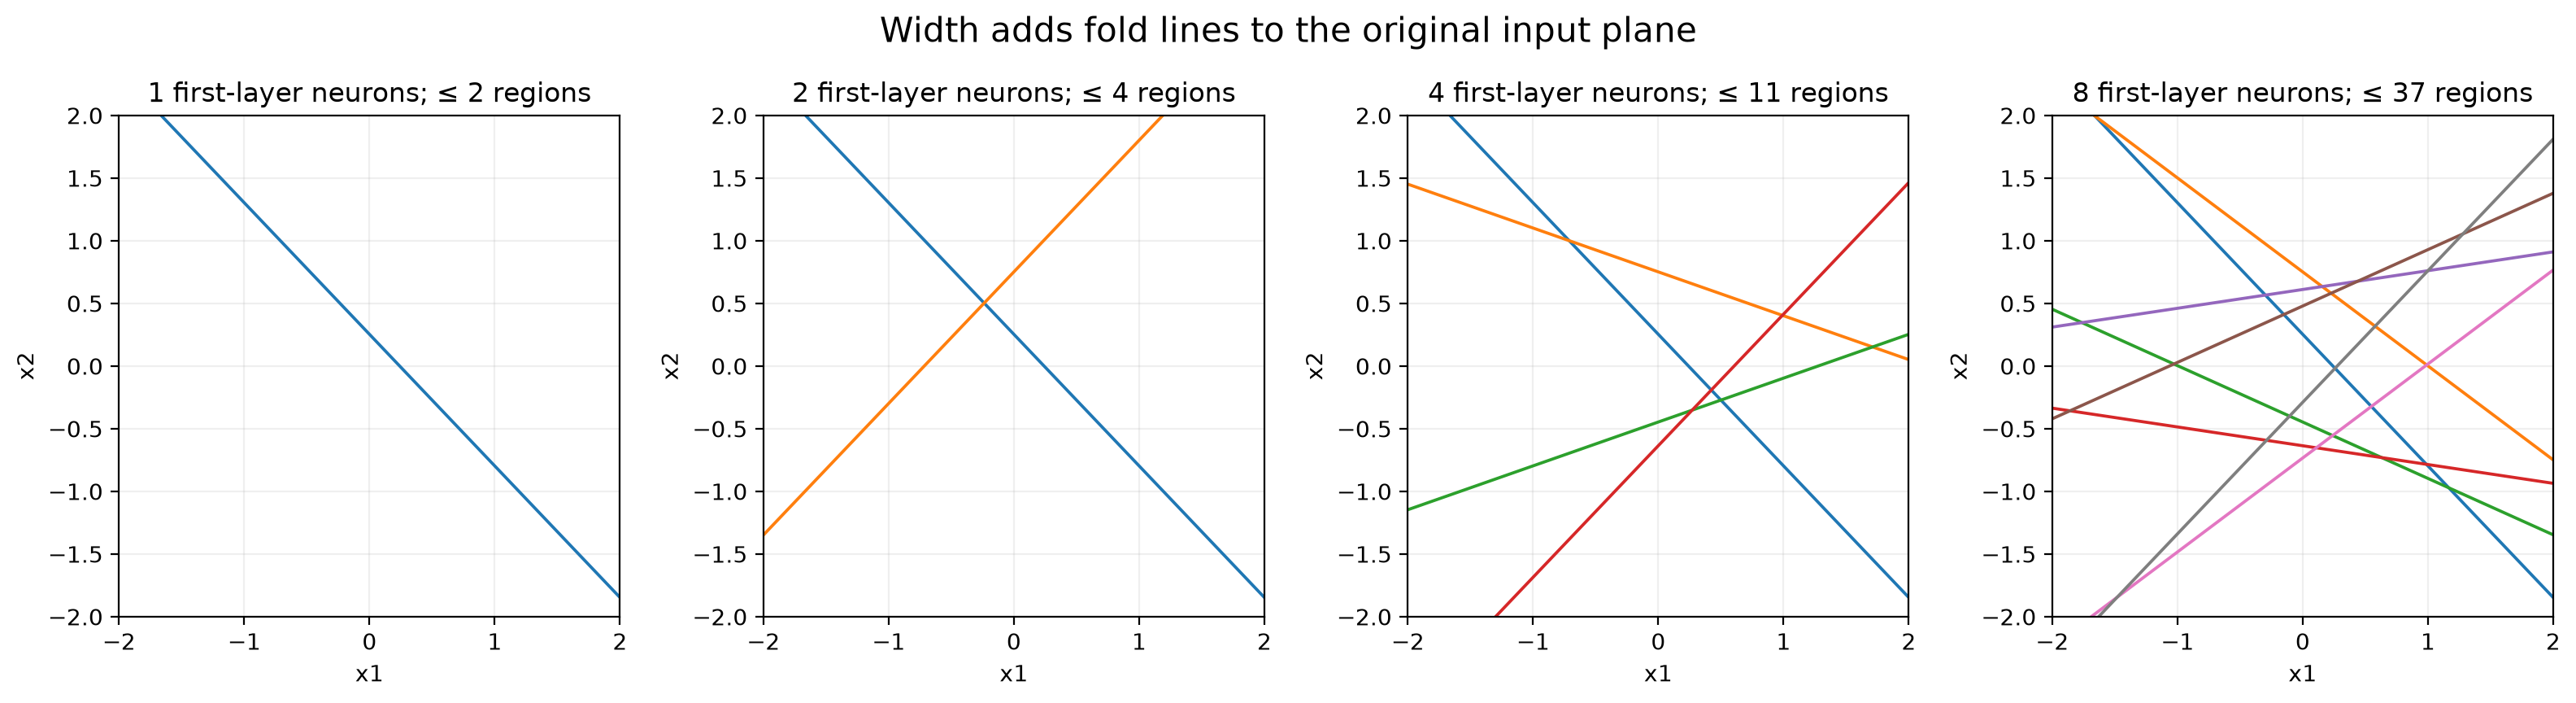

neurons | maximum 2D regions (general position)
       1 |      2
       2 |      4
       4 |     11
       8 |     37
      16 |    137
      32 |    529


In [3]:
def line_arrangement(m):
    # Fixed deterministic slopes/intercepts with no deliberately concurrent pattern.
    slopes=np.linspace(-1.05,1.05,m)
    intercepts=.83*np.sin(1.7*np.arange(m)+.31)
    return zip(slopes,intercepts)
fig,axs=plt.subplots(1,4,figsize=(16,4))
xx=np.linspace(-2,2,500)
for ax,m in zip(axs,[1,2,4,8]):
    for slope,offset in line_arrangement(m): ax.plot(xx,slope*xx+offset,lw=1.35)
    ax.set(xlim=(-2,2),ylim=(-2,2),xlabel='x1',ylabel='x2',aspect='equal',title=f'{m} first-layer neurons; ≤ {1+m*(m+1)//2} regions')
fig.suptitle('Width adds fold lines to the original input plane',fontsize=15,y=1.02)
plt.tight_layout(); plt.show()
print('neurons | maximum 2D regions (general position)')
for m in [1,2,4,8,16,32]: print(f'{m:8d} | {1+m*(m+1)//2:6d}')

The arrangement gives the next layer more cells in which it could use a different affine rule. It does not force the final boundary to cross every cell. Some folds can be redundant, irrelevant to the data, or never become useful during training. The number of available regions is therefore a capacity bound, not a prediction of the boundary a trained model will produce.

## 4. Depth: a later neuron folds an already-folded surface

Width and depth do different jobs. In the shallow spline, every ReLU unit sees the original coordinate `x1`, so each unit contributes one new knot. With depth, a later neuron receives the output of an earlier layer. That output is already piecewise linear, so the later ReLU can cross zero on several of its pieces.

The tent map makes this exact. On `[0, 1]`,

```text
T(x) = 2x                 for x <= 1/2
       2(1 - x)           for x >= 1/2
```

It has two linear pieces. Composing it with itself doubles the number of pieces again. The code below writes the tent map with ReLUs and plots the composition so that the multiplication comes from composition, not from changing the plotting scale.

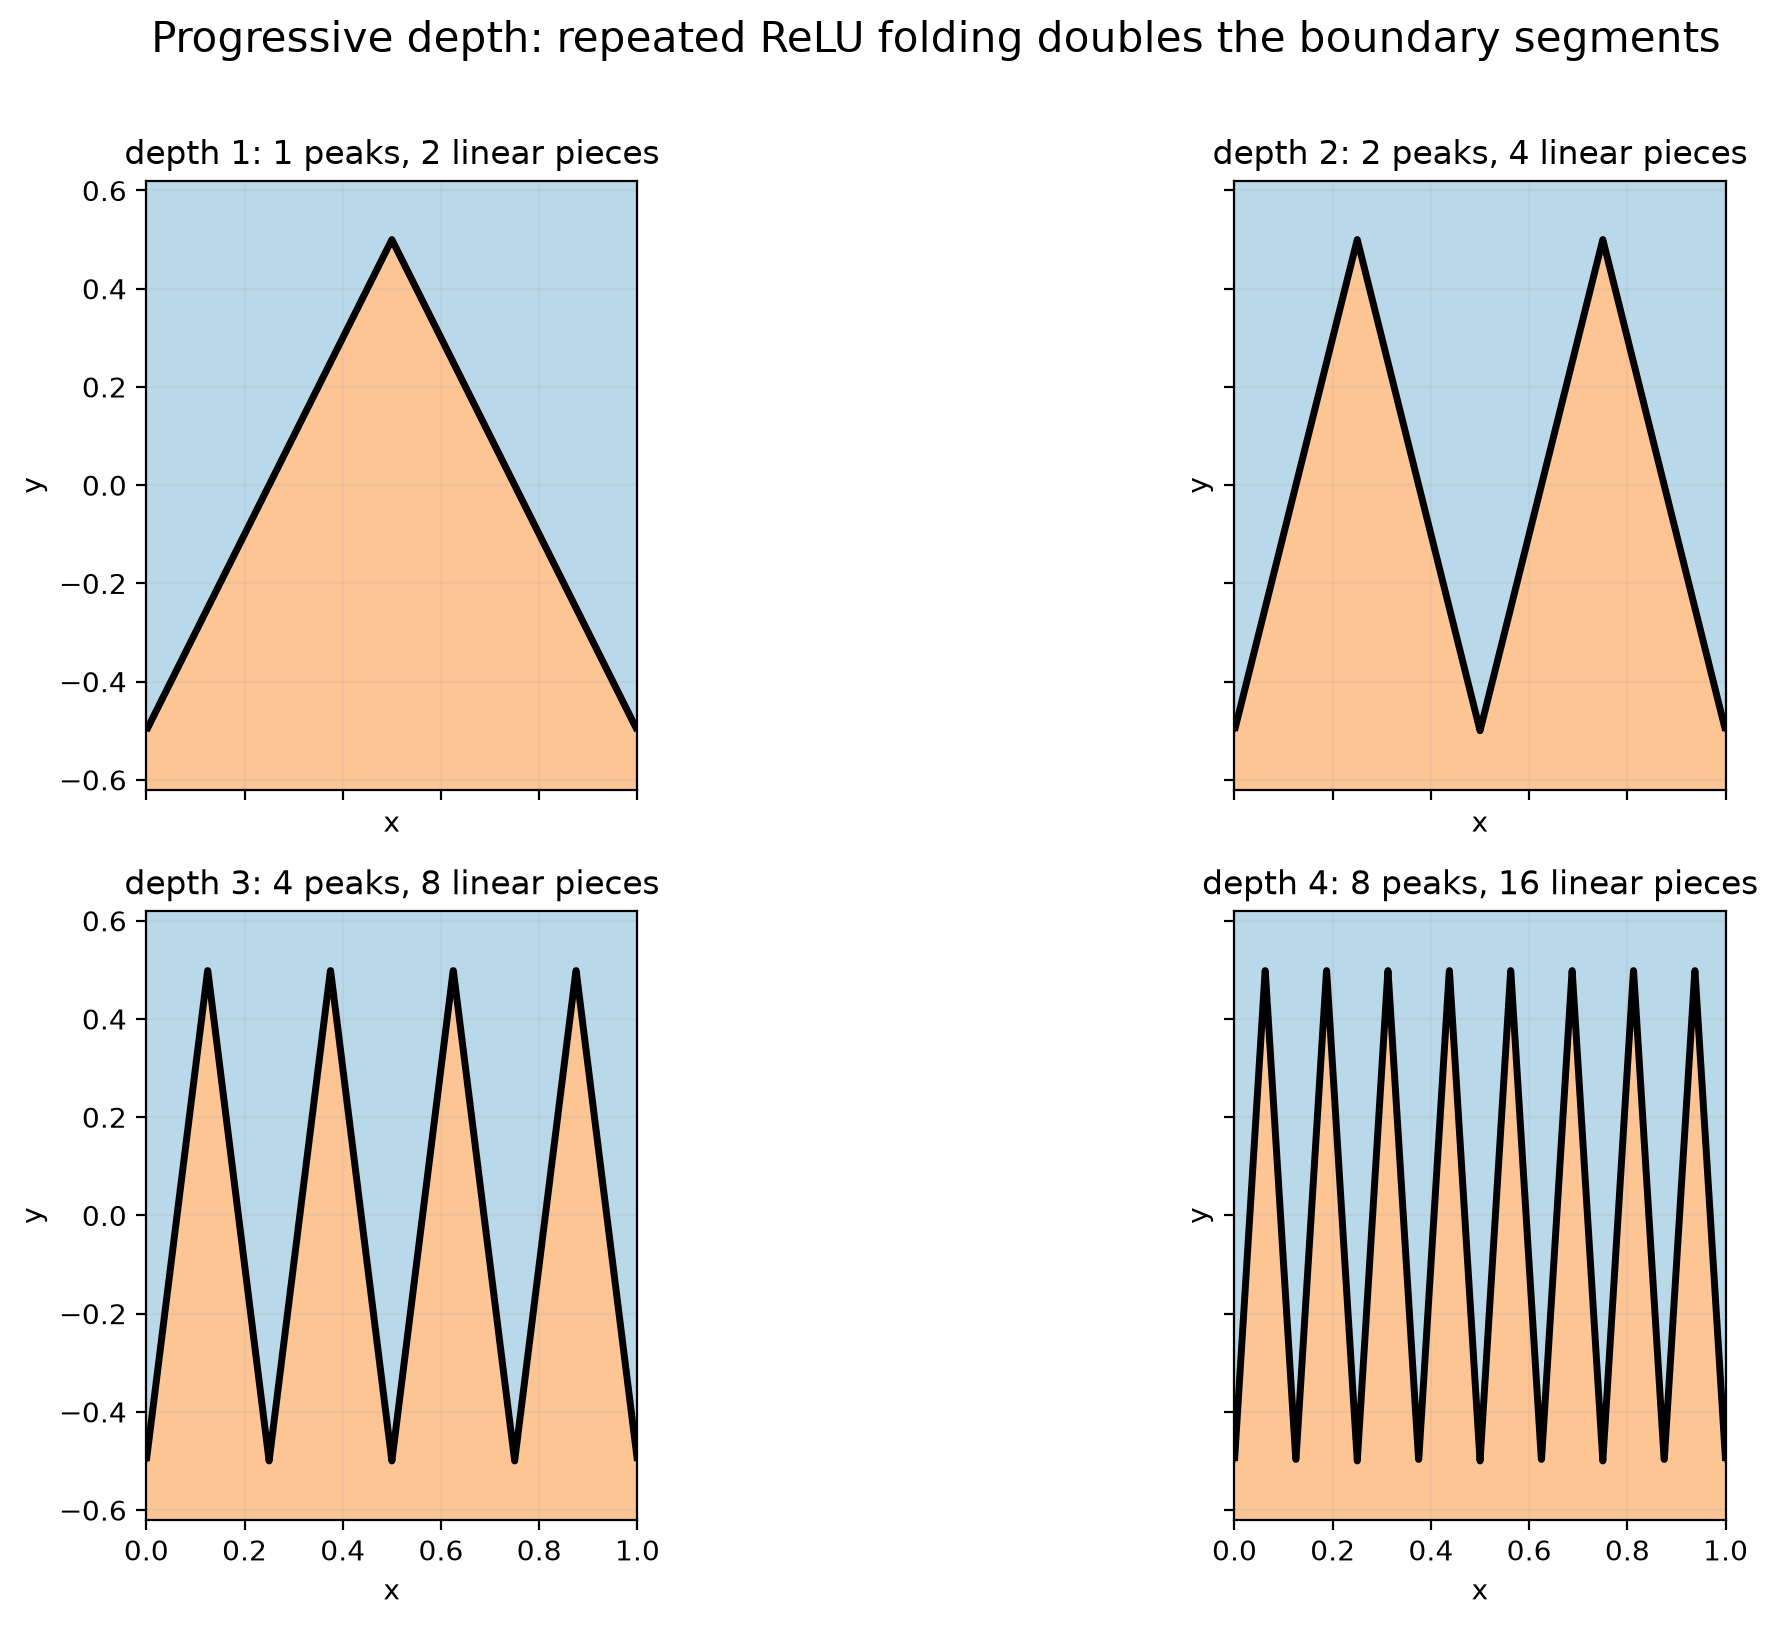

In [4]:
def tent(x):
    # Exact ReLU expression on [0,1].
    return 2*relu(x) - 4*relu(x-.5) + 2*relu(x-1.)

def tent_iterate(x, depth):
    out=np.asarray(x,dtype=float)
    for _ in range(depth): out=tent(out)
    return out

xline=np.linspace(0,1,2501)
yline=np.linspace(-.62,.62,500)
XX,YY=np.meshgrid(xline,yline)
depths=[1,2,3,4]
fig,axs=plt.subplots(2,2,figsize=(13,8),sharex=True,sharey=True)
for ax,d in zip(axs.flat,depths):
    f=tent_iterate(XX,d)-.5
    g=f-YY
    ax.contourf(XX,YY,g,levels=[g.min(),0,g.max()],colors=['#9ecae1','#fdae6b'],alpha=.72)
    ax.contour(XX,YY,g,levels=[0],colors='black',linewidths=2.5)
    ax.plot(xline,tent_iterate(xline,d)-.5,color='black',lw=1.1,alpha=.65)
    ax.set(title=f'depth {d}: {2**(d-1)} peaks, {2**d} linear pieces',xlabel='x',ylabel='y',xlim=(0,1),ylim=(-.62,.62),aspect='equal')
fig.suptitle('Progressive depth: repeated ReLU folding doubles the boundary segments',fontsize=15,y=1.01)
plt.tight_layout(); plt.show()

Each panel applies one more copy of the same two-piece map. The number of pieces doubles: 2, 4, 8, then 16. Nothing in a single layer made sixteen folds directly. The later layer received a surface that was already piecewise linear and folded each of its pieces again.

The two experiments now have the same interpretation. Width adds more ReLU units that see the original input. Depth reuses the output of earlier ReLU units, so a later unit can act on several pieces at once. That composition is why depth can create a much richer partition with fewer total units.

The universal approximation theorem says that a sufficiently wide shallow network can represent any continuous function on a compact domain, under the theorem’s assumptions. It does not say how wide the network must be or how gradient descent will find the parameters.

For classification, the network represents continuous score surfaces. The hard boundary is their equality contour. A complicated border can therefore be approximated by continuous piecewise-linear scores even though the final class labels jump across the contour.

## Summary

One ReLU neuron folds the input along one affine line. Adding neurons to the same layer adds more candidate folds to the original plane. Adding layers changes the surface being folded, so later neurons can create several new pieces when viewed in the original coordinates.

The region-count formulas describe what the architecture can represent. The trained panels show what a particular initialization, optimizer, and training budget actually find. Keeping those two statements separate is the main lesson.

## 7. The same boundary after training

The constructions above chose their weights so that the geometry was transparent. We now remove that convenience. The data, loss, optimizer, initialization rule, and number of updates are held fixed; only width or depth changes. Each panel shows the training points, the two score regions, and the contour where the scores tie.

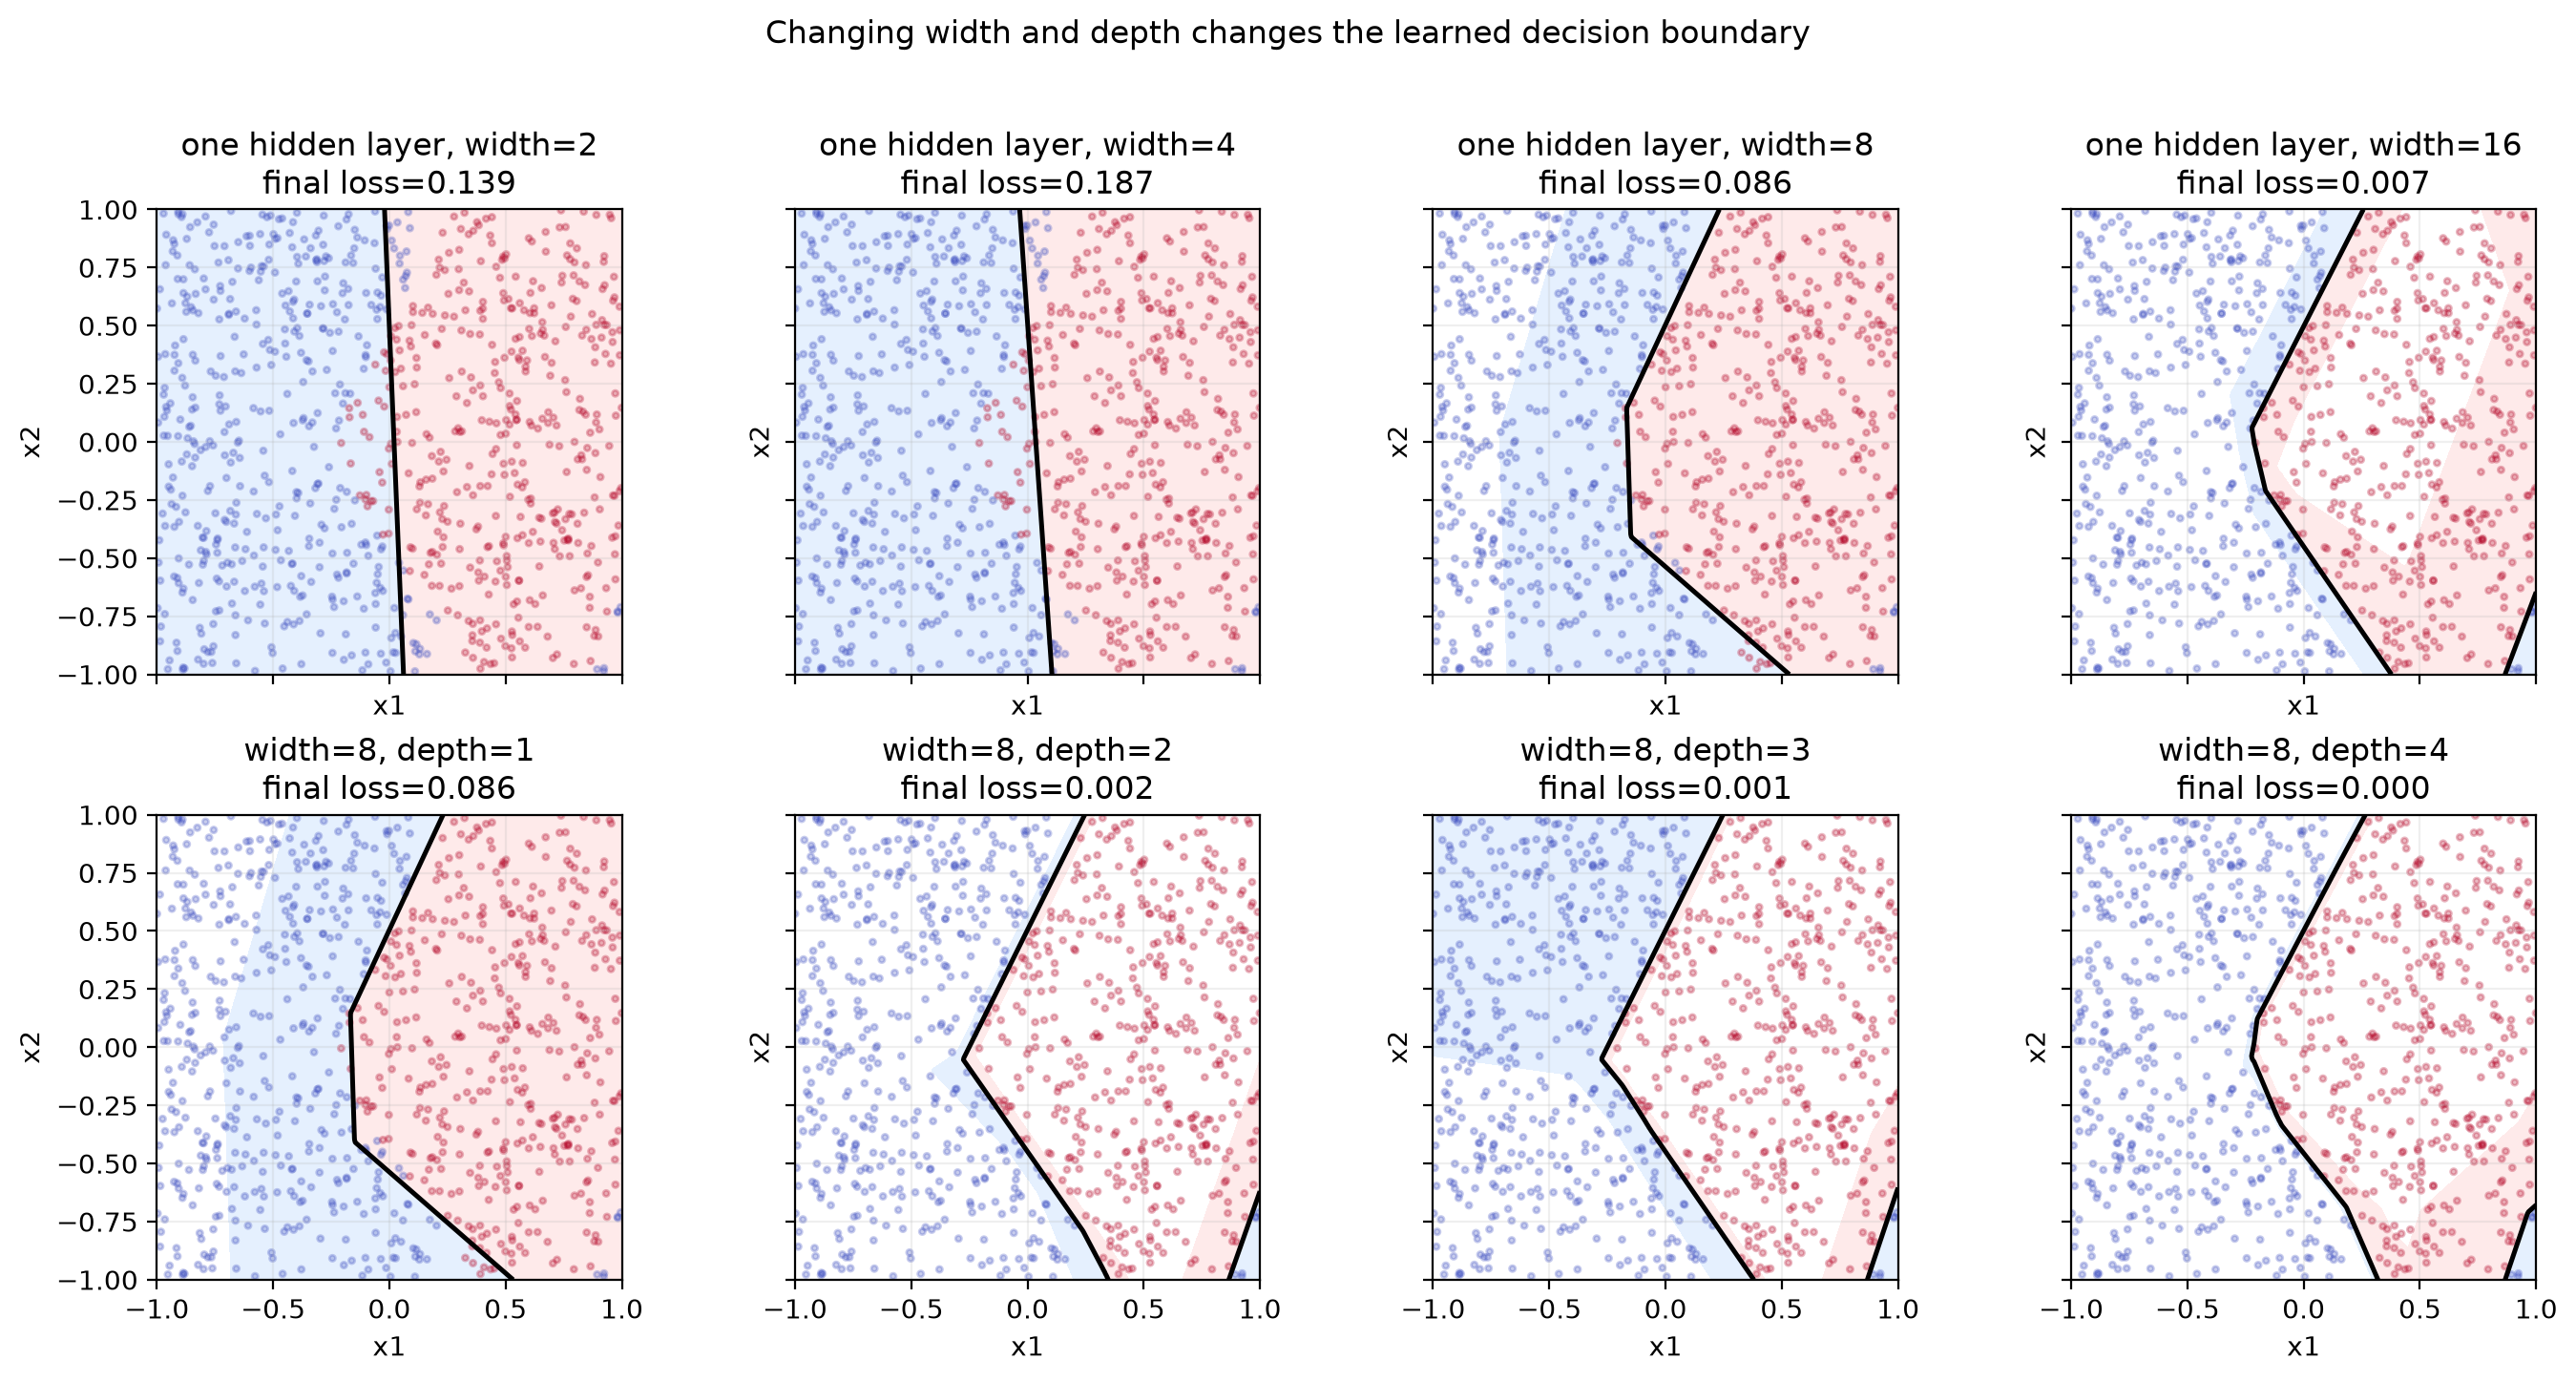

In [5]:
import torch
from torch import nn

torch.manual_seed(12)
torch.set_num_threads(1)
rng = np.random.default_rng(12)
train = rng.uniform(-1, 1, size=(900, 2)).astype('float32')
target_score = (np.sin(2.6 * train[:, 0]) + 0.55 * np.cos(3.4 * train[:, 1]) + 0.25 * train[:, 0] * train[:, 1])
labels = (target_score > 0).astype('float32')
X_train = torch.from_numpy(train)
y_train = torch.from_numpy(labels[:, None])

def make_classifier(width, depth):
    layers = [nn.Linear(2, width), nn.ReLU()]
    for _ in range(depth - 1): layers += [nn.Linear(width, width), nn.ReLU()]
    layers += [nn.Linear(width, 1)]
    return nn.Sequential(*layers)

def fit_classifier(width, depth, epochs=1600):
    torch.manual_seed(1000 + 10 * width + depth)
    model = make_classifier(width, depth)
    opt = torch.optim.Adam(model.parameters(), lr=0.02)
    loss_fn = nn.BCEWithLogitsLoss()
    history = []
    for _ in range(epochs):
        loss = loss_fn(model(X_train), y_train)
        opt.zero_grad(); loss.backward(); opt.step(); history.append(loss.item())
    return model, history

grid_x, grid_y = np.meshgrid(np.linspace(-1, 1, 240), np.linspace(-1, 1, 240))
grid = torch.from_numpy(np.c_[grid_x.ravel(), grid_y.ravel()].astype('float32'))

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=True, sharey=True)
for ax, width in zip(axes[0], [2, 4, 8, 16]):
    model, history = fit_classifier(width, depth=1)
    with torch.no_grad(): z = model(grid).numpy().reshape(grid_x.shape)
    ax.contourf(grid_x, grid_y, z, levels=[-20, 0, 20], colors=['#dbeafe', '#fee2e2'], alpha=.7)
    ax.contour(grid_x, grid_y, z, levels=[0], colors='black', linewidths=1.8)
    ax.scatter(train[:, 0], train[:, 1], c=labels, cmap='coolwarm', s=5, alpha=.28)
    ax.set_title(f'one hidden layer, width={width}\nfinal loss={history[-1]:.3f}')
for ax, depth in zip(axes[1], [1, 2, 3, 4]):
    model, history = fit_classifier(width=8, depth=depth)
    with torch.no_grad(): z = model(grid).numpy().reshape(grid_x.shape)
    ax.contourf(grid_x, grid_y, z, levels=[-20, 0, 20], colors=['#dbeafe', '#fee2e2'], alpha=.7)
    ax.contour(grid_x, grid_y, z, levels=[0], colors='black', linewidths=1.8)
    ax.scatter(train[:, 0], train[:, 1], c=labels, cmap='coolwarm', s=5, alpha=.28)
    ax.set_title(f'width=8, depth={depth}\nfinal loss={history[-1]:.3f}')
for ax in axes.ravel(): ax.set(xlim=(-1, 1), ylim=(-1, 1), xlabel='x1', ylabel='x2'); ax.set_aspect('equal')
fig.suptitle('Changing width and depth changes the learned decision boundary', y=1.02)
fig.tight_layout()
plt.show()

The top row keeps one hidden layer and gives it more ReLU units. The boundary gains more possible turns, but the extra units are useful only where the data require them. The bottom row keeps the width fixed and adds layers. The later folds act on already-bent features, so their effect can appear as several bends in the original plane.

These panels connect the geometry to learning. Width and depth change the set of boundaries the model can express; optimization determines which one is actually reached.

## 8. Compare equal-size models and watch them learn

The number of neurons alone is not a fair efficiency comparison. A layer also has weights connecting it to the previous layer, so we compare parameter counts as well. The table below uses the same width and depth choices as the boundary figure.

In [6]:
def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters())


for width in [2, 4, 8, 16]:
    shallow_model = make_classifier(width=width, depth=1)
    print(f'shallow width={width:>2}: {parameter_count(shallow_model):>4} parameters')

for depth in [1, 2, 3, 4]:
    deep_model = make_classifier(width=8, depth=depth)
    print(f'depth={depth}: width=8, {parameter_count(deep_model):>4} parameters')

shallow width= 2:    9 parameters
shallow width= 4:   17 parameters
shallow width= 8:   33 parameters
shallow width=16:   65 parameters
depth=1: width=8,   33 parameters
depth=2: width=8,  105 parameters
depth=3: width=8,  177 parameters
depth=4: width=8,  249 parameters


The comparison is deliberately modest: depth does not automatically use fewer parameters for every width. Its advantage is that the same parameters can be composed, allowing later ReLU units to act on features that already contain multiple linear pieces.

To see the learning process rather than only the final result, we now save the boundary after a few training checkpoints. The architecture and data stay fixed within each row. The columns show what gradient descent has found early, partway through training, and at the end.

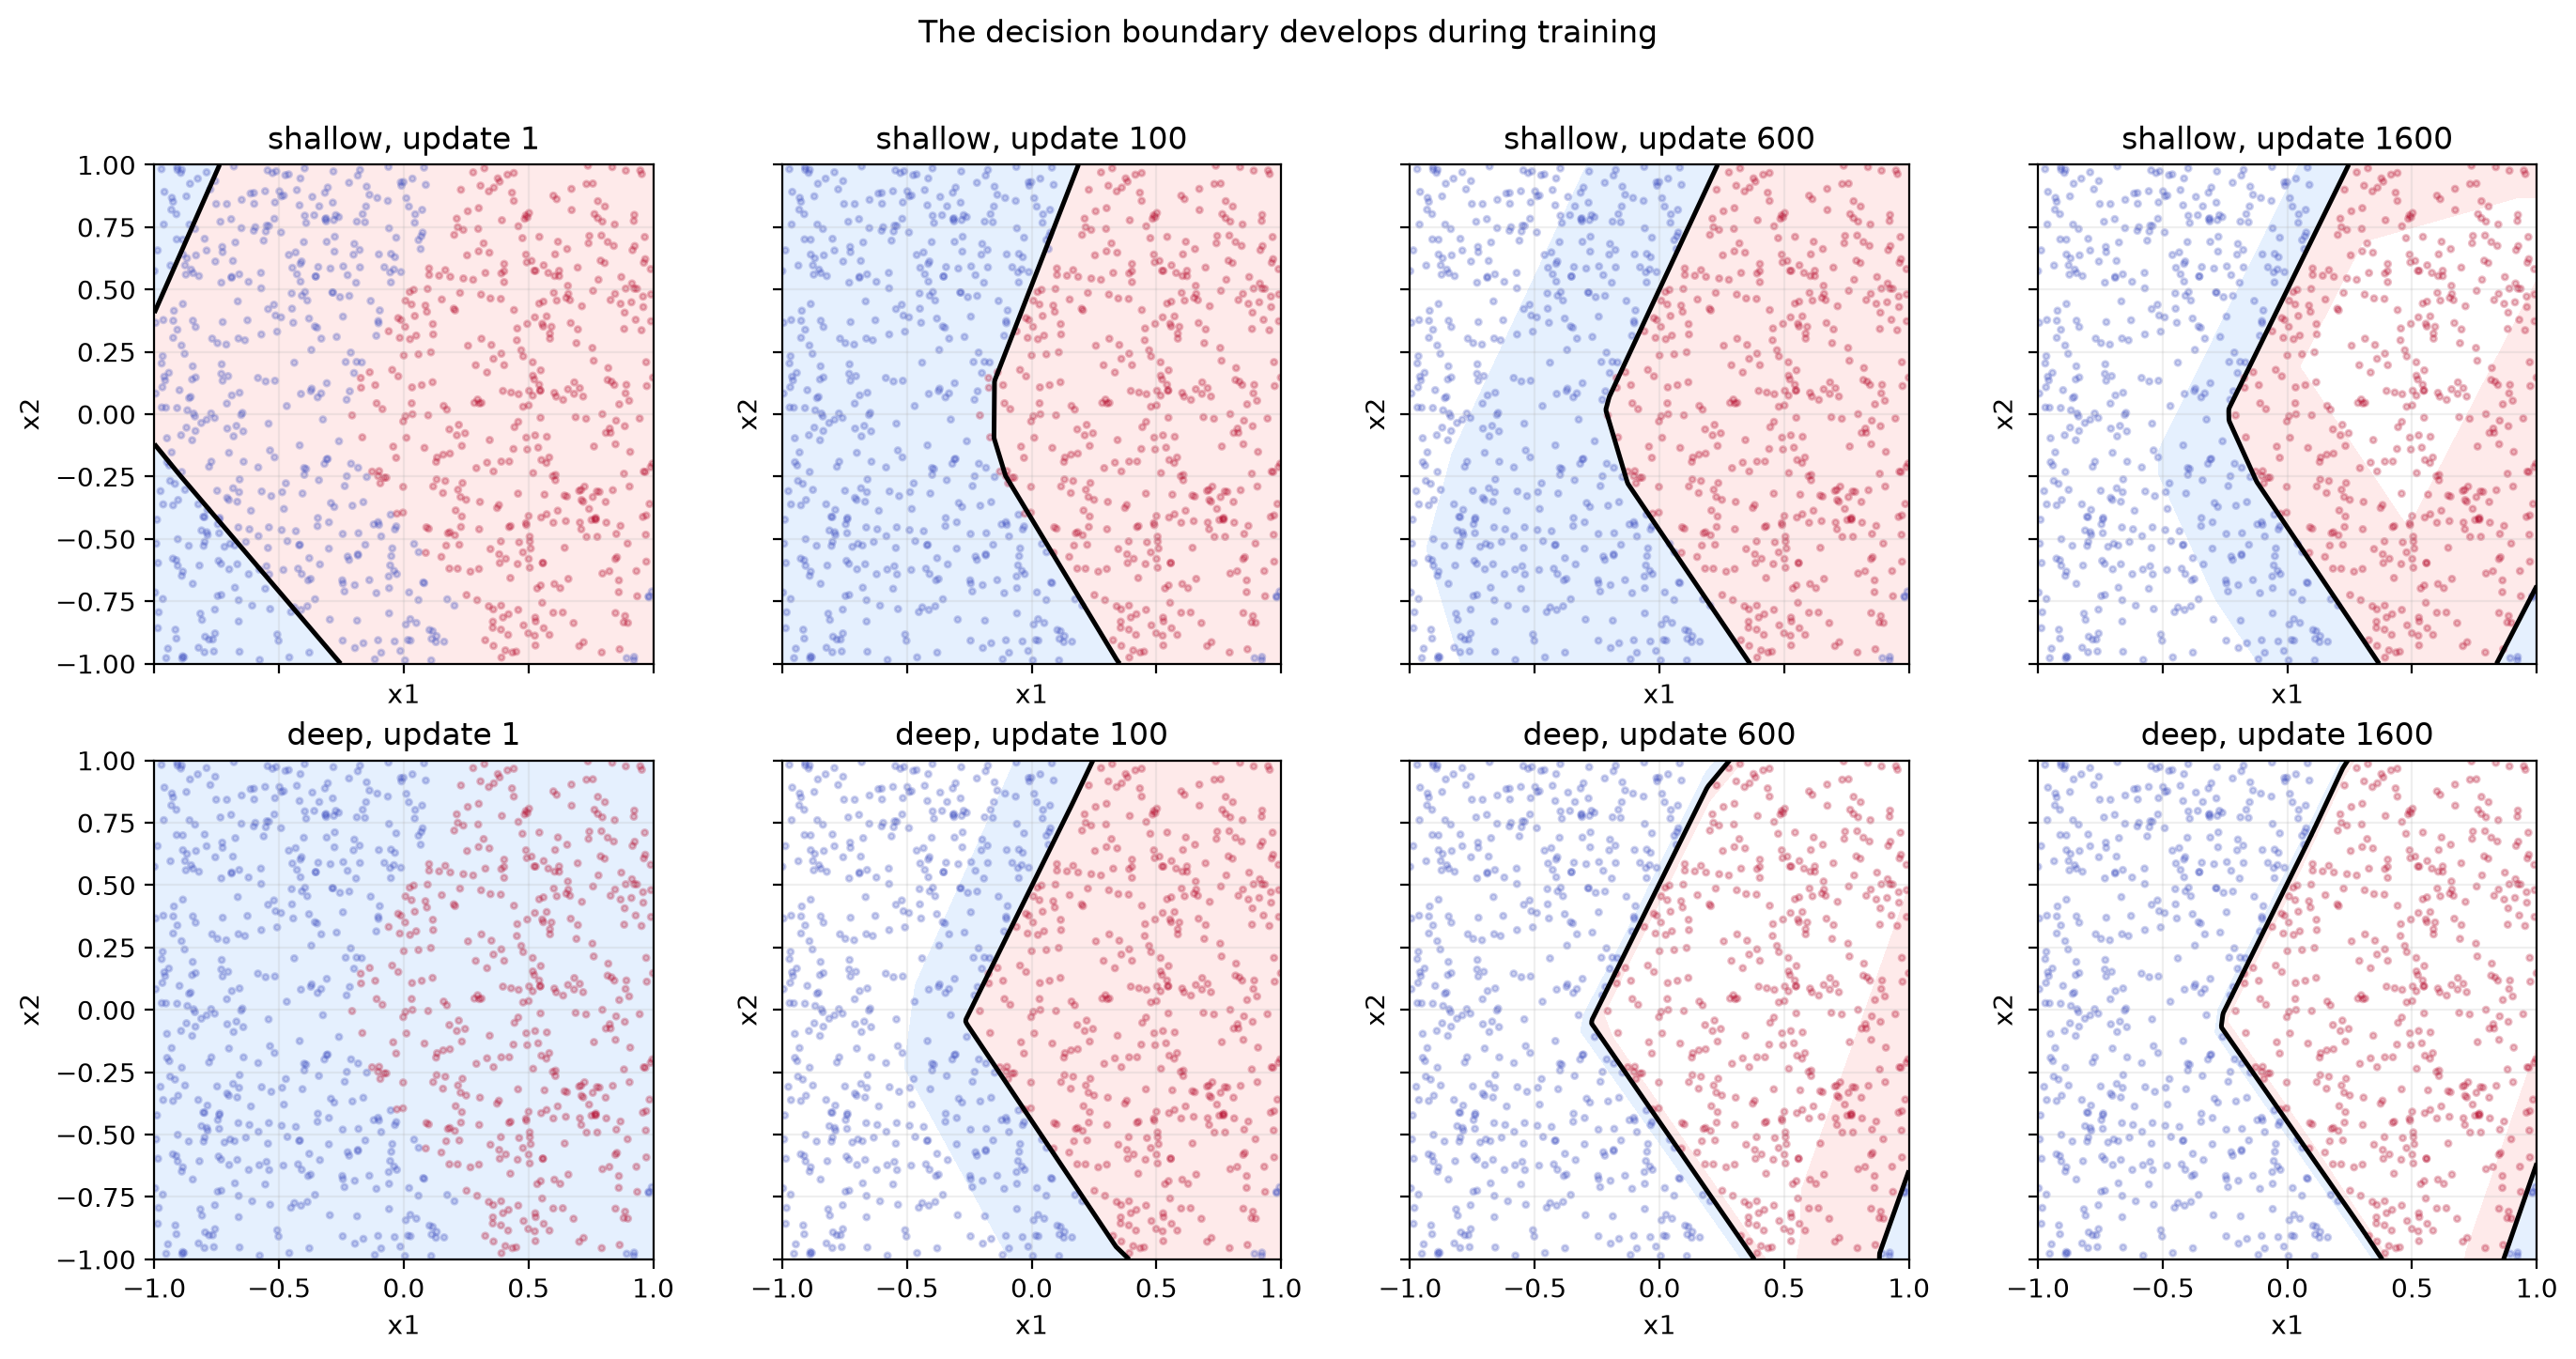

In [7]:
def fit_with_checkpoints(width, depth, checkpoints=(1, 100, 600, 1600)):
    torch.manual_seed(3000 + 10 * width + depth)
    model = make_classifier(width, depth)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
    loss_function = nn.BCEWithLogitsLoss()
    saved_models = {}
    last_checkpoint = max(checkpoints)

    for step in range(1, last_checkpoint + 1):
        loss = loss_function(model(X_train), y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step in checkpoints:
            saved_models[step] = {name: value.detach().clone() for name, value in model.state_dict().items()}

    return model, saved_models


checkpoint_steps = [1, 100, 600, 1600]
fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=True, sharey=True)

for row, (width, depth, label) in enumerate([(8, 1, 'shallow'), (8, 3, 'deep')]):
    final_model, saved_states = fit_with_checkpoints(width, depth, checkpoint_steps)
    for axis, step in zip(axes[row], checkpoint_steps):
        checkpoint_model = make_classifier(width, depth)
        checkpoint_model.load_state_dict(saved_states[step])
        with torch.no_grad():
            score_grid = checkpoint_model(grid).numpy().reshape(grid_x.shape)
        axis.contourf(grid_x, grid_y, score_grid, levels=[-20, 0, 20], colors=['#dbeafe', '#fee2e2'], alpha=.7)
        axis.contour(grid_x, grid_y, score_grid, levels=[0], colors='black', linewidths=1.8)
        axis.scatter(train[:, 0], train[:, 1], c=labels, cmap='coolwarm', s=5, alpha=.25)
        axis.set_title(f'{label}, update {step}')
        axis.set(xlim=(-1, 1), ylim=(-1, 1), xlabel='x1', ylabel='x2')
        axis.set_aspect('equal')

fig.suptitle('The decision boundary develops during training', y=1.02)
fig.tight_layout()
plt.show()

The early panels show a boundary determined mostly by the random initialization. Later updates move the score contour toward the structure in the data. The deep row can change several local pieces through one composed update, but it is still subject to the same optimization limits as the shallow row. This is the practical difference between a model’s representational capacity and the solution gradient descent actually reaches.